In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def generate_histogram(image):
    histogram=cv2.calcHist(
        [image],
        [0],#for grey scale no plane,no rgb
        None,#for mask whole image will be considered as 1 mask s we are ot divinding the image to get parts to do local operations
        [256], #no of bins,no. of levels aas 8 bit imaage
        [0,256]#[0,256)
    )
    return histogram
    

In [41]:
input_path=r"pic4.png"
input_image=cv2.imread(input_path)

gray_image=cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY)

In [42]:
input_image.shape

(210, 210, 3)

In [43]:
gray_image.shape    

(210, 210)

In [44]:
input_hist=generate_histogram(gray_image)

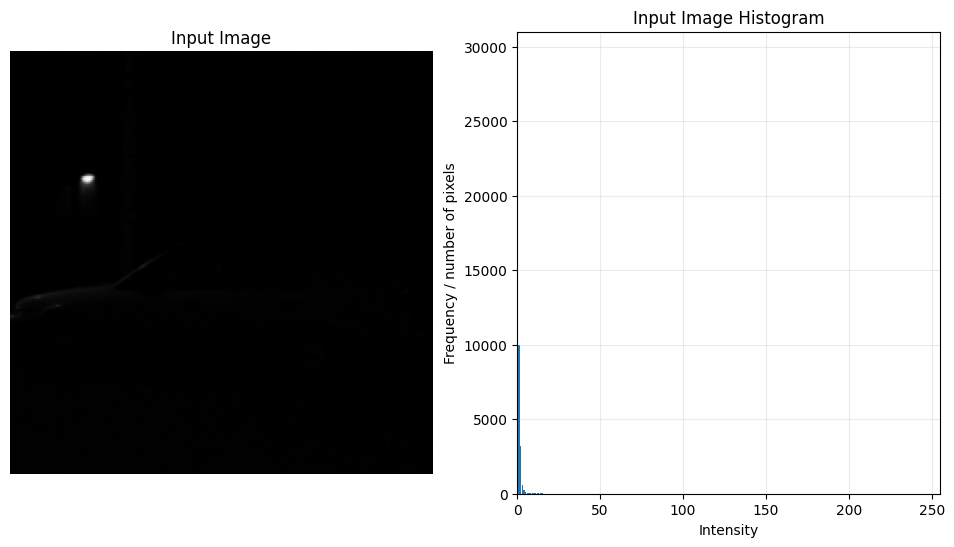

In [45]:
input_path=r"pic4.png"
input_image=cv2.imread(input_path)

gray_image=cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY)

input_hist=generate_histogram(gray_image)

intensity=np.arange(256)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gray_image,cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.bar(intensity, input_hist)
plt.title("Input Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / number of pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

plt.show()

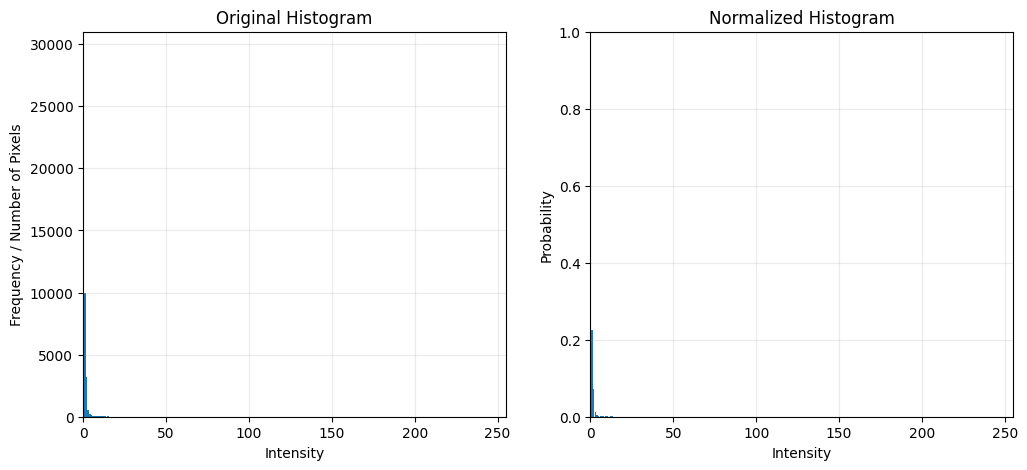

In [46]:
ttl_pi=gray_image.size
normalized_hist=input_hist/ttl_pi
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.bar(intensity,input_hist,width=1)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / Number of Pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Normalized histogram
plt.subplot(1, 2, 2)
plt.bar(intensity, normalized_hist)
plt.title("Normalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Probability")
plt.xlim([0, 255])
plt.ylim([0, 1])
plt.grid(alpha=0.25)

plt.show()

Histogram Equalisation

In [47]:
def hist_equalisation(image):
    gray_image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    equalised_image=cv2.equalizeHist(gray_image)
    return equalised_image

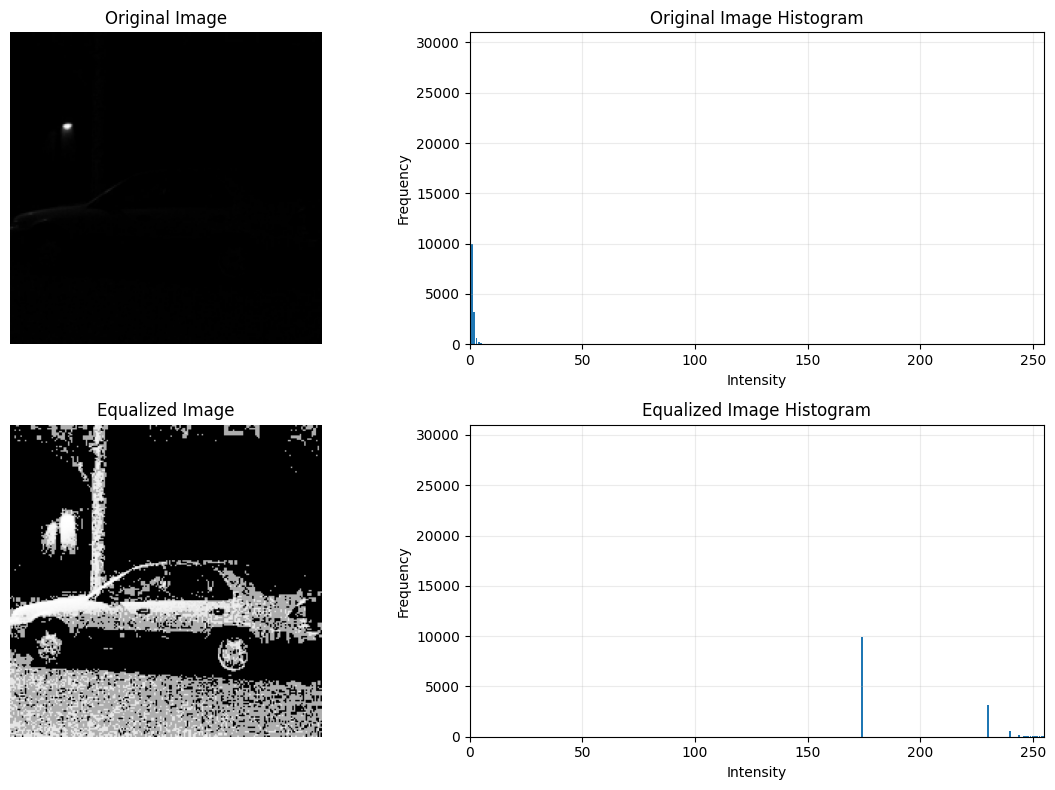

In [48]:
equalized_image = hist_equalisation(input_image)
original_hist=generate_histogram(gray_image)
equalized_hist=generate_histogram(equalized_image)
intensity=np.arange(256)
plt.figure(figsize=(12,8))

plt.subplot(2, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.bar(intensity, original_hist)
plt.title("Original Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# 3. Equalized Image
plt.subplot(2, 2, 3)
plt.imshow(equalized_image, cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

# 4. Equalized Histogram
plt.subplot(2, 2, 4)
plt.bar(intensity, equalized_hist)
plt.title("Equalized Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 255])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Histogram Matching

In [49]:
input_path = "pic4.png"
input_image = cv2.imread(input_path)

# Convert the image to grayscale
gray_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

# Load the reference image
reference_path = "image.png"
reference_image = cv2.imread(reference_path)

# Convert the reference image to grayscale
gray_reference = cv2.cvtColor(reference_image, cv2.COLOR_BGR2GRAY)


In [50]:
from skimage.exposure import match_histograms
#using sklearn library as cv does not have direct function of matching

In [51]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
# Perform histogram matching
matched_image = match_histograms(gray_image,gray_reference)
matched_image.dtype
# Convert the matched image to 8-bit format
matched_image = np.uint8(matched_image)

In [53]:
matched_image.dtype

dtype('uint8')

In [54]:
# Generate the histogram of the original image
original_hist = generate_histogram(gray_image)

# Generate the histogram of the reference image
reference_hist = generate_histogram(gray_reference)

# Generate the histogram of the matched image
matched_hist = generate_histogram(matched_image)

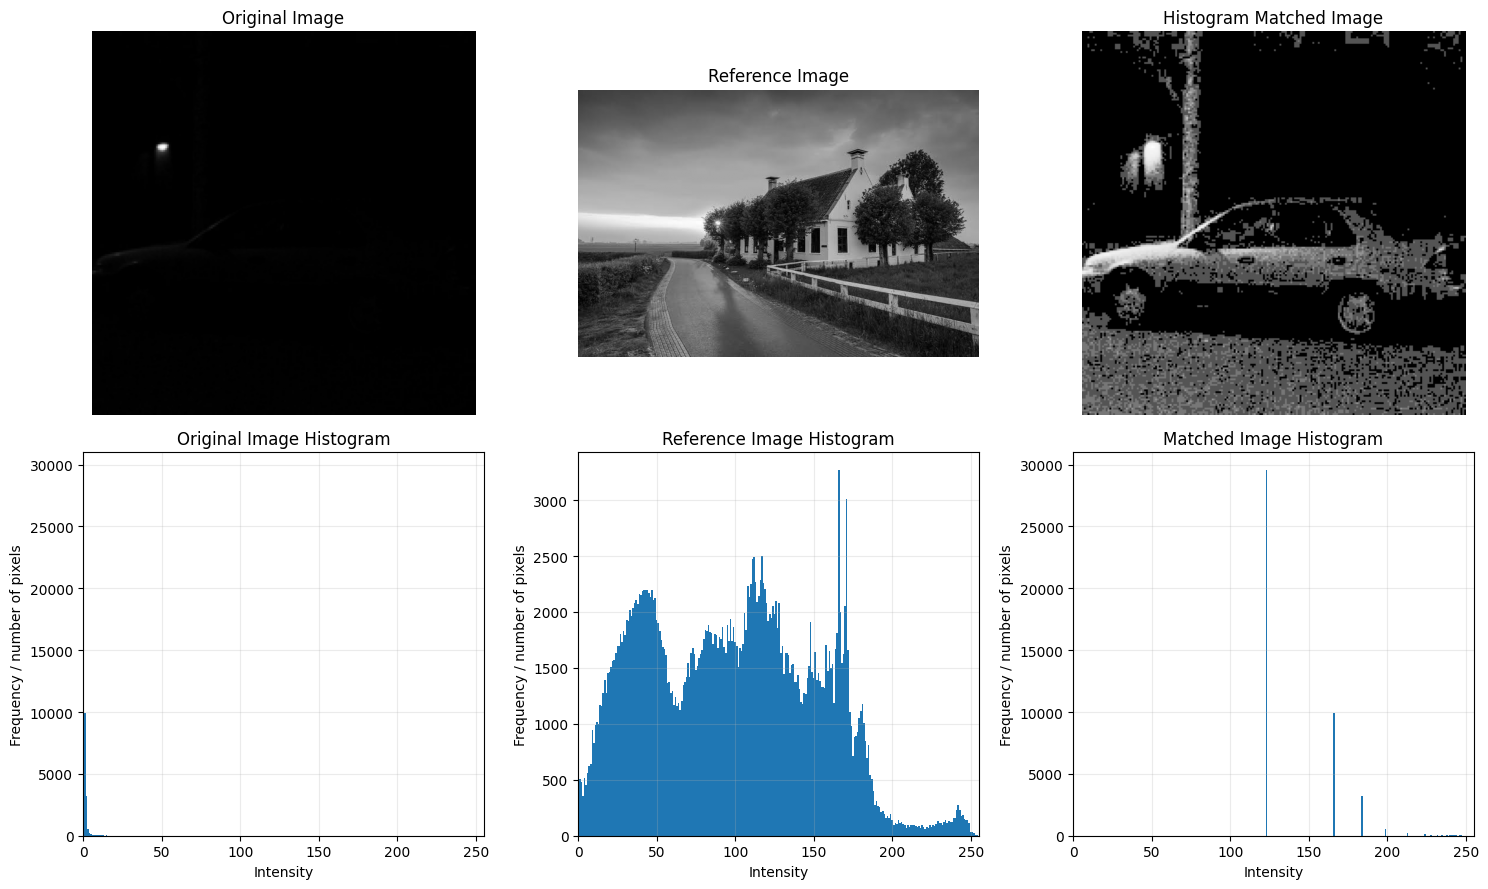

In [55]:
# Create intensity values from 0 to 255
intensity = np.arange(256)

# Display images and histograms
plt.figure(figsize=(15, 9))

# Display the original image
plt.subplot(2, 3, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Display the reference image
plt.subplot(2, 3, 2)
plt.imshow(gray_reference, cmap="gray")
plt.title("Reference Image")
plt.axis("off")

# Display the matched image
plt.subplot(2, 3, 3)
plt.imshow(matched_image, cmap="gray")
plt.title("Histogram Matched Image")
plt.axis("off")

# Display the original histogram
plt.subplot(2, 3, 4)
plt.bar(intensity, original_hist, width=1)
plt.title("Original Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / number of pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Display the reference histogram
plt.subplot(2, 3, 5)
plt.bar(intensity, reference_hist, width=1)
plt.title("Reference Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / number of pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Display the matched histogram
plt.subplot(2, 3, 6)
plt.bar(intensity, matched_hist, width=1)
plt.title("Matched Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency / number of pixels")
plt.xlim([0, 255])
plt.grid(alpha=0.25)

# Adjust spacing
plt.tight_layout()

# Display the results
plt.show()